# KNN Classification Analysis for All Datasets

This notebook applies KNN classification with feature selection and cross-validation to all three datasets:
1. **Telco Customer Churn** - Predicting customer churn
2. **Online Shoppers Intention** - Predicting purchase intention
3. **Bank Marketing** - Predicting term deposit subscription

## Import Required Libraries

In [114]:
import numpy as np               
import pandas as pd              
import matplotlib.pyplot as plt  
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import SelectKBest, SelectPercentile, chi2
from sklearn.neighbors import KNeighborsClassifier   
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.pipeline import Pipeline
from sklearn import preprocessing                    
from sklearn.preprocessing import MinMaxScaler       
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Libraries imported successfully!")
TELCO_PATH = "../data/processed/telco_clean.csv"
BANK_PATH = "../data/processed/bank_clean.csv"
ECOM_PATH = "../data/processed/ecom_clean.csv"

Libraries imported successfully!


---
## 1. Telco Customer Churn Dataset

### Load and Explore Data

In [115]:
telco_path = TELCO_PATH
df_telco = pd.read_csv(telco_path)

print(f"Dataset shape: {df_telco.shape}")
print(f"\nFirst few rows:")
print(df_telco.head())
print(f"\nColumn names:")
print(df_telco.columns.tolist())
print(f"\nData types:")
print(df_telco.dtypes)
print(f"\nMissing values:")
print(df_telco.isnull().sum())

Dataset shape: (7043, 21)

First few rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Strea

### Preprocessing and Feature Engineering

In [116]:
X_telco = df_telco.iloc[:, 2:20]  # Feature columns
y_telco = df_telco['Churn']        # Target variable

print(f"Features shape: {X_telco.shape}")
print(f"Target shape: {y_telco.shape}")

X_telco['TotalCharges'] = pd.to_numeric(X_telco['TotalCharges'], errors='coerce')
X_telco['TotalCharges'] = X_telco['TotalCharges'].fillna(X_telco['TotalCharges'].median())

telco_continuous = X_telco.select_dtypes(include=[np.number]).columns.tolist()
telco_categorical = X_telco.select_dtypes(include=['object']).columns.tolist()

print(f"\nContinuous features ({len(telco_continuous)}): {telco_continuous}")
print(f"Categorical features ({len(telco_categorical)}): {telco_categorical}")

if telco_continuous:
    print(f"\nScaling {len(telco_continuous)} continuous features...")
    X_telco[telco_continuous] = MinMaxScaler().fit_transform(X_telco[telco_continuous])

if telco_categorical:
    print(f"Encoding {len(telco_categorical)} categorical features...")
    X_telco = pd.get_dummies(X_telco, columns=telco_categorical, drop_first=True, dtype=float)
else:
    print("No categorical features - converting all to float")
    X_telco = X_telco.astype(float)

print(f"Shape after encoding: {X_telco.shape}")

X_telco = X_telco.fillna(0)
X_telco = X_telco.clip(lower=0)

## y_telco = (y_telco == 'Yes').astype(int)  # 'Yes' -> 1, 'No' -> 0##

print(f"\nFinal Features after encoding shape: {X_telco.shape}")
print(f"Feature names (first 20): {X_telco.columns.tolist()[:20]}")
print(f"Target variable distribution:")
print(y_telco.value_counts())

Features shape: (7043, 18)
Target shape: (7043,)

Continuous features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (14): ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Scaling 4 continuous features...
Encoding 14 categorical features...
Shape after encoding: (7043, 29)

Final Features after encoding shape: (7043, 29)
Feature names (first 20): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet 

### Feature Selection

In [117]:
X_telco_selected = SelectPercentile(score_func=chi2, percentile=10).fit_transform(X_telco, y_telco)
print(f"Features after selection shape: {X_telco_selected.shape}")

X_telco_train, X_telco_valid, y_telco_train, y_telco_valid = train_test_split(
    X_telco_selected, y_telco, train_size=0.7, stratify=y_telco, random_state=42
)

print(f"\nTraining set size: {X_telco_train.shape[0]}")
print(f"Validation set size: {X_telco_valid.shape[0]}")

Features after selection shape: (7043, 3)

Training set size: 4930
Validation set size: 2113


### Scaling and Model Training

In [118]:
telco_scaler = preprocessing.StandardScaler().fit(X_telco_train)
X_telco_train_scaled = telco_scaler.transform(X_telco_train)
X_telco_valid_scaled = telco_scaler.transform(X_telco_valid)

knn_telco = KNeighborsClassifier(n_neighbors=7)
knn_telco.fit(X_telco_train_scaled, y_telco_train)

cv_scores_telco = cross_val_score(knn_telco, X_telco_train_scaled, y_telco_train, cv=5)
print(f"Cross-validation scores: {cv_scores_telco}")
print(f"Mean CV score: {cv_scores_telco.mean():.4f} (+/- {cv_scores_telco.std():.4f})")

acc_telco_train = knn_telco.score(X_telco_train_scaled, y_telco_train) * 100
acc_telco_valid = knn_telco.score(X_telco_valid_scaled, y_telco_valid) * 100
print(f"\nAccuracy on training data: {acc_telco_train:.2f}%")
print(f"Accuracy on validation data: {acc_telco_valid:.2f}%")

Cross-validation scores: [0.73529412 0.73833671 0.73427992 0.7535497  0.73427992]
Mean CV score: 0.7391 (+/- 0.0074)

Accuracy on training data: 71.38%
Accuracy on validation data: 71.94%


### Model Evaluation

Confusion Matrix:
Predicted     0    1
Actual              
0          1142  410
1           183  378


<Figure size 800x600 with 0 Axes>

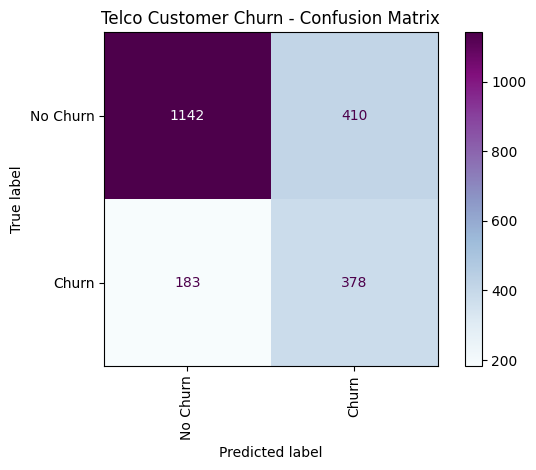

In [119]:
y_telco_pred = knn_telco.predict(X_telco_valid_scaled)

print("Confusion Matrix:")
cm_telco = pd.crosstab(y_telco_valid, y_telco_pred, rownames=['Actual'], colnames=['Predicted'])
print(cm_telco)

cm_telco_values = confusion_matrix(y_telco_valid, y_telco_pred, labels=knn_telco.classes_)
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_telco_values, display_labels=['No Churn', 'Churn']).plot(cmap='BuPu')
plt.title('Telco Customer Churn - Confusion Matrix')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

---
## 2. Online Shoppers Intention Dataset

### Load and Explore Data

In [120]:
online_path = "online_shoppers_intention.csv"
df_online = pd.read_csv(ECOM_PATH)

print(f"Dataset shape: {df_online.shape}")
print(f"\nFirst few rows:")
print(df_online.head())
print(f"\nColumn names:")
print(df_online.columns.tolist())
print(f"\nData types:")
print(df_online.dtypes)
print(f"\nMissing values:")
print(df_online.isnull().sum())

Dataset shape: (12205, 18)

First few rows:
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00

### Preprocessing and Feature Engineering

In [121]:
target_col_online = df_online.columns[-1]
print(f"Target column: {target_col_online}")

X_online = df_online.drop(columns=[target_col_online])
y_online = df_online[target_col_online]

print(f"\nFeatures shape: {X_online.shape}")
print(f"Target shape: {y_online.shape}")
print(f"Target variable distribution:")
print(y_online.value_counts())

online_continuous = X_online.select_dtypes(include=[np.number]).columns.tolist()
online_categorical = X_online.select_dtypes(include=['object']).columns.tolist()

print(f"\nContinuous features: {online_continuous}")
print(f"Categorical features: {online_categorical}")

Target column: Revenue

Features shape: (12205, 17)
Target shape: (12205,)
Target variable distribution:
Revenue
0    10297
1     1908
Name: count, dtype: int64

Continuous features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
Categorical features: ['Month', 'VisitorType']


In [122]:
if online_continuous:
    X_online[online_continuous] = MinMaxScaler().fit_transform(X_online[online_continuous])

if online_categorical:
    X_online = pd.get_dummies(X_online, drop_first=True)

for col in X_online.columns:
    X_online[col] = pd.to_numeric(X_online[col], errors='coerce')

X_online = X_online.fillna(0)
X_online = X_online.clip(lower=0)

if y_online.dtype == 'object':
    y_online = (y_online == y_online.unique()[1]).astype(int)

print(f"Features after encoding shape: {X_online.shape}")
print(f"Target variable distribution:")
print(y_online.value_counts())

Features after encoding shape: (12205, 26)
Target variable distribution:
Revenue
0    10297
1     1908
Name: count, dtype: int64


### Feature Selection

In [123]:
X_online_selected = SelectPercentile(score_func=chi2, percentile=10).fit_transform(X_online, y_online)
print(f"Features after selection shape: {X_online_selected.shape}")

X_online_train, X_online_valid, y_online_train, y_online_valid = train_test_split(
    X_online_selected, y_online, train_size=0.7, stratify=y_online, random_state=42
)

print(f"\nTraining set size: {X_online_train.shape[0]}")
print(f"Validation set size: {X_online_valid.shape[0]}")

Features after selection shape: (12205, 3)

Training set size: 8543
Validation set size: 3662


### Scaling and Model Training

In [124]:
online_scaler = preprocessing.StandardScaler().fit(X_online_train)
X_online_train_scaled = online_scaler.transform(X_online_train)
X_online_valid_scaled = online_scaler.transform(X_online_valid)

knn_online = KNeighborsClassifier(n_neighbors=7)
knn_online.fit(X_online_train_scaled, y_online_train)

cv_scores_online = cross_val_score(knn_online, X_online_train_scaled, y_online_train, cv=5)
print(f"Cross-validation scores: {cv_scores_online}")
print(f"Mean CV score: {cv_scores_online.mean():.4f} (+/- {cv_scores_online.std():.4f})")

acc_online_train = knn_online.score(X_online_train_scaled, y_online_train) * 100
acc_online_valid = knn_online.score(X_online_valid_scaled, y_online_valid) * 100
print(f"\nAccuracy on training data: {acc_online_train:.2f}%")
print(f"Accuracy on validation data: {acc_online_valid:.2f}%")

Cross-validation scores: [0.89350497 0.87653599 0.8923347  0.89051522 0.88466042]
Mean CV score: 0.8875 (+/- 0.0063)

Accuracy on training data: 91.12%
Accuracy on validation data: 88.64%


### Model Evaluation

Confusion Matrix:
Predicted     0    1
Actual              
0          2926  164
1           252  320


<Figure size 800x600 with 0 Axes>

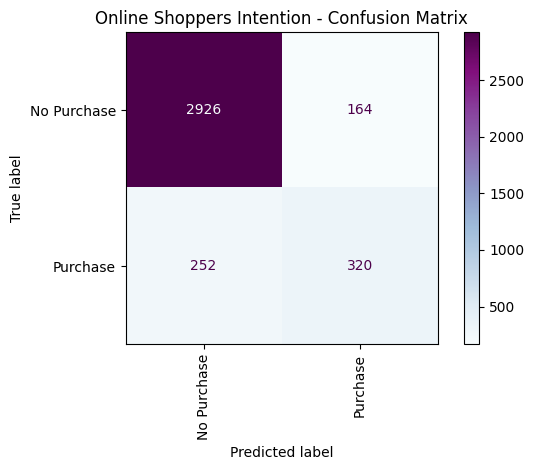

In [125]:
y_online_pred = knn_online.predict(X_online_valid_scaled)

print("Confusion Matrix:")
cm_online = pd.crosstab(y_online_valid, y_online_pred, rownames=['Actual'], colnames=['Predicted'])
print(cm_online)

cm_online_values = confusion_matrix(y_online_valid, y_online_pred, labels=knn_online.classes_)
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_online_values, display_labels=['No Purchase', 'Purchase']).plot(cmap='BuPu')
plt.title('Online Shoppers Intention - Confusion Matrix')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

---
## 3. Bank Marketing Dataset

### Load and Explore Data

In [126]:
bank_path = "bank-additional-full.csv"
df_bank = pd.read_csv(BANK_PATH)

print(f"Dataset shape: {df_bank.shape}")
print(f"\nFirst few rows:")
print(df_bank.head())
print(f"\nColumn names:")
print(df_bank.columns.tolist())
print(f"\nData types:")
print(df_bank.dtypes)
print(f"\nMissing values:")
print(df_bank.isnull().sum())

Dataset shape: (41176, 21)

First few rows:
   age        job  marital    education default housing loan    contact month  \
0   56  housemaid  married     basic.4y      no      no   no  telephone   may   
1   57   services  married  high.school      no      no   no  telephone   may   
2   37   services  married  high.school      no     yes   no  telephone   may   
3   40     admin.  married     basic.6y      no      no   no  telephone   may   
4   56   services  married  high.school      no      no  yes  telephone   may   

  day_of_week  ...  campaign  pdays  previous  poutcome emp.var.rate  \
0         mon  ...         1    6.0         0   failure          1.1   
1         mon  ...         1    6.0         0   failure          1.1   
2         mon  ...         1    6.0         0   failure          1.1   
3         mon  ...         1    6.0         0   failure          1.1   
4         mon  ...         1    6.0         0   failure          1.1   

   cons.price.idx  cons.conf.idx  eu

### Preprocessing and Feature Engineering

In [127]:
target_col_bank = df_bank.columns[-1]
print(f"Target column: {target_col_bank}")

X_bank = df_bank.drop(columns=[target_col_bank])
y_bank = df_bank[target_col_bank]

print(f"\nFeatures shape: {X_bank.shape}")
print(f"Target shape: {y_bank.shape}")
print(f"Target variable distribution:")
print(y_bank.value_counts())

bank_continuous = X_bank.select_dtypes(include=[np.number]).columns.tolist()
bank_categorical = X_bank.select_dtypes(include=['object']).columns.tolist()

print(f"\nContinuous features: {bank_continuous}")
print(f"Categorical features: {bank_categorical}")

Target column: y

Features shape: (41176, 20)
Target shape: (41176,)
Target variable distribution:
y
0    36537
1     4639
Name: count, dtype: int64

Continuous features: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [128]:
print("DEBUG - Raw X_bank after drop:")
print(f"Shape: {X_bank.shape}")
print(f"Columns: {X_bank.columns.tolist()}")
print(f"Dtypes:\n{X_bank.dtypes}")

if bank_continuous:
    print(f"Scaling continuous features: {bank_continuous}")
    X_bank[bank_continuous] = MinMaxScaler().fit_transform(X_bank[bank_continuous])
else:
    print("No continuous features found")

print(f"\nAfter scaling - Shape: {X_bank.shape}")

if bank_categorical:
    print(f"Encoding categorical features: {bank_categorical}")
    X_bank = pd.get_dummies(X_bank, columns=bank_categorical, drop_first=True, dtype=float)
else:
    print("No categorical features found - converting to float")
    X_bank = X_bank.astype(float)

print(f"After encoding - Shape: {X_bank.shape}")
print(f"Columns after encoding: {X_bank.columns.tolist()}")

X_bank = X_bank.astype(float)
X_bank = X_bank.fillna(0)
X_bank = X_bank.clip(lower=0)

if y_bank.dtype == 'object':
    y_bank = (y_bank == y_bank.unique()[1]).astype(int)

print(f"\nFinal Features after encoding shape: {X_bank.shape}")
print(f"Features dtype: {X_bank.dtypes.unique()}")
print(f"Features min: {X_bank.min().min()}, max: {X_bank.max().max()}")
print(f"Target variable distribution:")
print(y_bank.value_counts())

DEBUG - Raw X_bank after drop:
Shape: (41176, 20)
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Dtypes:
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays             float64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
dtype: object
Scaling continuous features: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'

### Feature Selection

In [129]:
X_bank_array = np.asarray(X_bank, dtype=np.float64)

X_bank_selected = SelectPercentile(score_func=chi2, percentile=10).fit_transform(X_bank_array, y_bank)
print(f"\nFeatures after selection shape: {X_bank_selected.shape}")

X_bank_train, X_bank_valid, y_bank_train, y_bank_valid = train_test_split(
    X_bank_selected, y_bank, train_size=0.7, stratify=y_bank, random_state=42
)

print(f"Training set size: {X_bank_train.shape[0]}")
print(f"Validation set size: {X_bank_valid.shape[0]}")


Features after selection shape: (41176, 5)
Training set size: 28823
Validation set size: 12353


### Scaling and Model Training

In [130]:
bank_scaler = preprocessing.StandardScaler().fit(X_bank_train)
X_bank_train_scaled = bank_scaler.transform(X_bank_train)
X_bank_valid_scaled = bank_scaler.transform(X_bank_valid)

knn_bank = KNeighborsClassifier(n_neighbors=7)
knn_bank.fit(X_bank_train_scaled, y_bank_train)

cv_scores_bank = cross_val_score(knn_bank, X_bank_train_scaled, y_bank_train, cv=5)
print(f"Cross-validation scores: {cv_scores_bank}")
print(f"Mean CV score: {cv_scores_bank.mean():.4f} (+/- {cv_scores_bank.std():.4f})")

acc_bank_train = knn_bank.score(X_bank_train_scaled, y_bank_train) * 100
acc_bank_valid = knn_bank.score(X_bank_valid_scaled, y_bank_valid) * 100
print(f"\nAccuracy on training data: {acc_bank_train:.2f}%")
print(f"Accuracy on validation data: {acc_bank_valid:.2f}%")

Cross-validation scores: [0.87441457 0.89575022 0.89418907 0.89659958 0.89208883]
Mean CV score: 0.8906 (+/- 0.0082)

Accuracy on training data: 90.24%
Accuracy on validation data: 89.35%


### Model Evaluation

Confusion Matrix:
Predicted      0    1
Actual               
0          10682  279
1           1037  355


<Figure size 800x600 with 0 Axes>

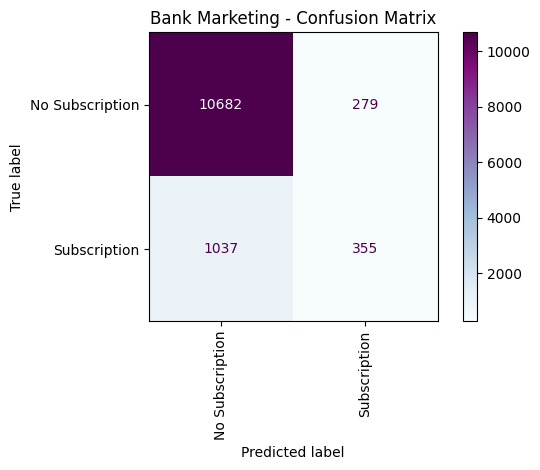

In [131]:
y_bank_pred = knn_bank.predict(X_bank_valid_scaled)

print("Confusion Matrix:")
cm_bank = pd.crosstab(y_bank_valid, y_bank_pred, rownames=['Actual'], colnames=['Predicted'])
print(cm_bank)

cm_bank_values = confusion_matrix(y_bank_valid, y_bank_pred, labels=knn_bank.classes_)
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_bank_values, display_labels=['No Subscription', 'Subscription']).plot(cmap='BuPu')
plt.title('Bank Marketing - Confusion Matrix')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

---
## Summary and Comparison

In [132]:
summary_data = {
    'Dataset': ['Telco Churn', 'Online Shoppers', 'Bank Marketing'],
    'Original Features': [X_telco.shape[1], X_online.shape[1], X_bank.shape[1]],
    'Selected Features': [X_telco_selected.shape[1], X_online_selected.shape[1], X_bank_selected.shape[1]],
    'Train Accuracy': [f"{acc_telco_train:.2f}%", f"{acc_online_train:.2f}%", f"{acc_bank_train:.2f}%"],
    'Valid Accuracy': [f"{acc_telco_valid:.2f}%", f"{acc_online_valid:.2f}%", f"{acc_bank_valid:.2f}%"],
    'Mean CV Score': [
        f"{cv_scores_telco.mean():.4f}",
        f"{cv_scores_online.mean():.4f}",
        f"{cv_scores_bank.mean():.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data).set_index("Dataset")
print("\nModel Performance Summary (K-Nearest Neighbors):")
display(summary_df)


Model Performance Summary (K-Nearest Neighbors):


,Original Features,Selected Features,Train Accuracy,Valid Accuracy,Mean CV Score
Dataset,,,,,
Telco Churn,29,3,71.38%,71.94%,0.7391
Online Shoppers,26,3,91.12%,88.64%,0.8875
Bank Marketing,46,5,90.24%,89.35%,0.8906
